# Проект: Линейные модели в машинном обучении
## Описание проекта
Мы работаем в IT-компании, которая выполняет на заказ проекты по машинному обучению. К нам обратился фермер, владелец молочного хозяйства «Вольный луг». Он хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма». 

Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. А продавцы и технологи так и норовят приукрасить своих коровок!

Поэтому он просит нас разработать модель машинного обучения, которая поможет ему управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Нам нужно создать две прогнозные модели для отбора бурёнок в поголовье: 
1. Первая будет прогнозировать возможный удой коровы (целевой признак `Удой`); 
2. Вторая — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак `Вкус молока`). 

С помощью модели нужно отобрать коров по двум критериям: 
- средний удой за год — не менее 6000 килограммов; 
- молоко должно быть вкусным.

1. Файл `ferma_main.csv` содержит данные о стаде фермера на текущий момент. Описание данных:

- `id` — уникальный идентификатор коровы.
- `Удой, кг` — масса молока, которую корова даёт в год (в килограммах).
- `ЭКЕ (Энергетическая кормовая единица)` — показатель питательности корма коровы.
- `Сырой протеин, г` — содержание сырого протеина в корме (в граммах).
- `СПО (Сахаро-протеиновое соотношение)` — отношение сахара к протеину в корме коровы.
- `Порода` — порода коровы.
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.
- `порода папы_быка` — порода папы коровы.
- `Жирность,%` — содержание жиров в молоке (в процентах).
- `Белок,%` — содержание белков в молоке (в процентах).
- `Вкус молока` — оценка вкуса по личным критериям фермера, бинарный признак (`вкусно`, `не вкусно`).
- `Возраст` — возраст коровы, бинарный признак (`менее_2_лет`, `более_2_лет`).

Признаки в датасете `ferma_main.csv` можно разделить на группы.
- Характеристики коровы: `id`, `Порода`, `порода папы_быка`, `Возраст`.
- Характеристики корма: `ЭКЕ (Энергетическая кормовая единица)`, `Сырой протеин, г`, `СПО (Сахаро-протеиновое соотношение)`.
- Характеристика пастбища: `Тип пастбища`.
- Характеристики молока: `Удой, кг`, `Жирность,%`, `Белок,%`, `Вкус молока`.

Такое разделение поможет нам понять, как взаимосвязаны признаки в датасете.

2. Файл `ferma_dad.csv` хранит имя папы каждой коровы в стаде фермера. Описание данных:

- `id` — уникальный идентификатор коровы.
- `Имя Папы` — имя папы коровы.

3. Файл `cow_buy.csv` — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Описание данных:

- `Порода` — порода коровы.
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.
- `порода папы_быка` — порода папы коровы.
- `Имя_папы` — имя папы коровы.
- `Текущая_жирность,%` — содержание жиров в молоке (в процентах).
- `Текущий_уровень_белок,%` — содержание белков в молоке (в процентах).
- `Возраст` — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).

Данные в файлах `ferma_main.csv` и `cow_buy.csv` похожи, но у датасета `cow_buy.csv` несколько особенностей.

- Содержание белков и жиров в молоке указано на момент продажи — когда «ЭкоФерма» давала коровам свой корм.
- Параметры корма `ЭКЕ (Энергетическая кормовая единица)`, `Сырой протеин, г` и `СПО (Сахаро-протеиновое соотношение)` отсутствуют. Технологи заказчика пересмотрели подход к кормлению: для новых коров планируется увеличить значения каждого из этих параметров на 5%.
- Кроме того, отсутствуют признаки `Удой, кг` и `Вкус молока`. Это целевые признаки, именно их предстоит предсказать!

# Загрузка данных

### Шаг 1. Загрузите и изучите данные

1. Загрузите данные в датафреймы pandas. Файлы можно скачать по ссылкам в описании, они даже доступны через пути:

- `/datasets/ferma_main.csv`

- `/datasets/ferma_dad.csv`

- `/datasets/cow_buy.csv`

2. Изучите данные. Определите, соответствуют ли они описанию задачи и изученным в прошлых спринтах стандартам оформления данных. При необходимости переименуйте столбцы.

In [1]:
!pip install phik -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import phik
import warnings
import warnings
warnings.filterwarnings("ignore")

from scipy import stats as st
from math import sqrt
from scipy.stats import binom, poisson
from math import factorial
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    r2_score,
    precision_score,
    mean_squared_error,
    mean_absolute_error,
    recall_score
)
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder 

In [3]:
pd.options.mode.chained_assignment = None

In [4]:
try:
    ferma = pd.read_csv('C:/Users/almuc/Downloads/ferma_main.csv', sep=';', decimal = ',')
    dad = pd.read_csv('C:/Users/almuc/Downloads/ferma_dad.csv', sep=';')
    cow_buy = pd.read_csv('C:/Users/almuc/Downloads/cow_buy.csv', sep=';', decimal = ',')
except:
    ferma = pd.read_csv('/datasets/ferma_main.csv', sep=';', decimal = ',')
    dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
    cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';', decimal = ',')

In [5]:
display(pd.DataFrame(ferma.head(10)))
ferma.info()
display(pd.DataFrame(dad.head(10)))
dad.info()
display(pd.DataFrame(cow_buy.head(10)))
cow_buy.info()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет
5,6,5254,12.7,1806,0.885,РефлешнСоверинг,Холмистое,Соверин,3.13,3.078,вкусно,менее_2_лет
6,7,5910,13.2,1792,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.48,3.077,вкусно,более_2_лет
7,8,6179,14.7,1806,0.930,Вис Бик Айдиал,Равнинные,Айдиал,3.55,3.076,вкусно,более_2_лет
8,9,6783,14.2,1918,0.940,РефлешнСоверинг,Холмистое,Айдиал,3.71,3.077,вкусно,более_2_лет
9,10,5339,13.4,1791,0.895,Вис Бик Айдиал,Холмистое,Соверин,3.13,3.075,вкусно,менее_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин
5,6,Барин
6,7,Соловчик
7,8,Геркулес
8,9,Буйный
9,10,Барин


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


In [6]:
# Создадим словарь для переименования столбцов
new_columns = {
    'id': 'id',
    'Удой, кг': 'milk_yield_kg',
    'ЭКЕ (Энергетическая кормовая единица)': 'energy_feed_unit',
    'Сырой протеин, г': 'crude_protein_g',
    'СПО (Сахаро-протеиновое соотношение)': 'sugar_protein_ratio',
    'Порода': 'breed',
    'Тип пастбища': 'grazing_type',
    'порода папы_быка': 'father_bull_breed',
    'Жирность,%': 'fat_percentage',
    'Белок,%': 'protein_percentage',
    'Вкус молока': 'milk_flavor',
    'Возраст': 'age'
}

ferma = ferma.rename(columns=new_columns)

In [7]:
# Сортируем список столбцов в алфавитном порядке
columns_to_sort = ferma.columns.tolist()
columns_to_sort.remove('id')

columns_sorted = sorted(columns_to_sort)
columns_sorted.insert(0, 'id')
ferma = ferma[columns_sorted]

ferma.head()

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio
0,1,более_2_лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,Равнинное,вкусно,5863,3.076,0.890
1,2,менее_2_лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,Равнинные,вкусно,5529,3.079,0.890
2,3,более_2_лет,РефлешнСоверинг,1854,14.0,3.59,Соверин,Холмистое,не вкусно,5810,3.074,0.885
3,4,более_2_лет,РефлешнСоверинг,2012,12.4,3.40,Айдиал,Холмистое,не вкусно,5895,3.075,0.885
4,5,менее_2_лет,Вис Бик Айдиал,1675,12.8,3.73,Соверин,Равнинные,вкусно,5302,3.073,0.885


In [8]:
new_columns = {
    'id': 'id',
    'Имя Папы': 'father_name'
}

dad = dad.rename(columns=new_columns)

dad.head()

,id,father_name
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [9]:
new_columns = {
    'Порода': 'breed',
    'Тип пастбища': 'grazing_type',
    'порода папы_быка': 'father_bull_breed',
    'Имя_папы': 'father_name',
    'Текущая_жирность,%': 'fat_percentage',
    'Текущий_уровень_белок,%': 'protein_percentage',
    'Возраст': 'age'
}

cow_buy = cow_buy.rename(columns=new_columns)
cow_buy = cow_buy.sort_index(axis=1)

cow_buy.head()

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage
0,более_2_лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076
1,менее_2_лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081
2,более_2_лет,РефлешнСоверинг,3.59,Соверин,Барин,равнинное,3.074
3,более_2_лет,РефлешнСоверинг,3.40,Айдиал,Буйный,холмистое,3.061
4,более_2_лет,РефлешнСоверинг,3.64,Айдиал,Буйный,равнинное,3.074


#### Вывод

На основании предварительного анализа можно утверждать, что в данных отсутствуют пропущенные значения. Также представляется целесообразным перевести значения столбцов на английский язык и привести их к нижнему регистру.

#  Предобработка данных

###  Шаг 2. Предобработка данных
Проверьте данные на наличие пропусков и дубликатов. Узнайте, корректны ли типы данных у каждого признака. При необходимости устраните все проблемы с данными.

In [10]:
# Выведем уникальные значения для столбцов
print(ferma['grazing_type'].unique())
print(ferma['father_bull_breed'].unique())
print(ferma['breed'].unique())
print(ferma['age'].unique())
print()
print(cow_buy['breed'].unique())
print(cow_buy['age'].unique())

['Равнинное' 'Равнинные' 'Холмистое']
['Айдиал' 'Соверин' 'Айдиалл']
['Вис Бик Айдиал' 'РефлешнСоверинг']
['более_2_лет' 'менее_2_лет']

['Вис Бик Айдиал' 'РефлешнСоверинг']
['более_2_лет' 'менее_2_лет']


In [11]:
ferma['grazing_type'] = ferma['grazing_type'].str.replace('ы', 'о').str.lower()
ferma['father_bull_breed'] = ferma['father_bull_breed'].str.replace('лл', 'л')
ferma['breed'] = ferma['breed'].replace('РефлешнСоверинг', 'Рефлешн Соверинг')
ferma['age'] = ferma['age'].str.replace('_', ' ')

cow_buy['breed'] = cow_buy['breed'].replace('РефлешнСоверинг', 'Рефлешн Соверинг')
cow_buy['age'] = cow_buy['age'].str.replace('_', ' ')

In [12]:
print(ferma['grazing_type'].unique())
print(ferma['father_bull_breed'].unique())
print(ferma['breed'].unique())
print(ferma['age'].unique())
print()
print(cow_buy['breed'].unique())
print(cow_buy['age'].unique())

['равнинное' 'холмистое']
['Айдиал' 'Соверин']
['Вис Бик Айдиал' 'Рефлешн Соверинг']
['более 2 лет' 'менее 2 лет']

['Вис Бик Айдиал' 'Рефлешн Соверинг']
['более 2 лет' 'менее 2 лет']


In [13]:
ferma.head()

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio
0,1,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,вкусно,5863,3.076,0.890
1,2,менее 2 лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,равнинное,вкусно,5529,3.079,0.890
2,3,более 2 лет,Рефлешн Соверинг,1854,14.0,3.59,Соверин,холмистое,не вкусно,5810,3.074,0.885
3,4,более 2 лет,Рефлешн Соверинг,2012,12.4,3.40,Айдиал,холмистое,не вкусно,5895,3.075,0.885
4,5,менее 2 лет,Вис Бик Айдиал,1675,12.8,3.73,Соверин,равнинное,вкусно,5302,3.073,0.885


In [14]:
cow_buy.head()

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074


In [15]:
print("Пропущенные значения:")
print(ferma.isna().sum().to_string())
print(ferma.shape)
print()
print("Дубликаты:")
print(ferma.duplicated().sum())
print()

print("Пропущенные значения:")
print(dad.isna().sum().to_string())
print(dad.shape)
print()
print("Дубликаты:")
print(dad.duplicated().sum())
print()

print("Пропущенные значения:")
print(cow_buy.isna().sum().to_string())
print(cow_buy.shape)
print()
print("Дубликаты:")
print(cow_buy.duplicated().sum())

Пропущенные значения:
id                     0
age                    0
breed                  0
crude_protein_g        0
energy_feed_unit       0
fat_percentage         0
father_bull_breed      0
grazing_type           0
milk_flavor            0
milk_yield_kg          0
protein_percentage     0
sugar_protein_ratio    0
(634, 12)

Дубликаты:
5

Пропущенные значения:
id             0
father_name    0
(629, 2)

Дубликаты:
0

Пропущенные значения:
age                   0
breed                 0
fat_percentage        0
father_bull_breed     0
father_name           0
grazing_type          0
protein_percentage    0
(20, 7)

Дубликаты:
4


In [16]:
# Удалим дубликаты 
print(len(ferma))
ferma = ferma.drop_duplicates().reset_index(drop = True)
print(len(ferma))

634
629


In [17]:
# Преобразуем столбцы в тип данных float32
columns_to_convert = ['energy_feed_unit', 'sugar_protein_ratio', 'fat_percentage', 'protein_percentage']
for col in columns_to_convert:
    ferma[col] = ferma[col].astype('float32')
ferma.dtypes

id                       int64
age                     object
breed                   object
crude_protein_g          int64
energy_feed_unit       float32
fat_percentage         float32
father_bull_breed       object
grazing_type            object
milk_flavor             object
milk_yield_kg            int64
protein_percentage     float32
sugar_protein_ratio    float32
dtype: object

In [18]:
ferma.head()

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio
0,1,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,вкусно,5863,3.076,0.890
1,2,менее 2 лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,равнинное,вкусно,5529,3.079,0.890
2,3,более 2 лет,Рефлешн Соверинг,1854,14.0,3.59,Соверин,холмистое,не вкусно,5810,3.074,0.885
3,4,более 2 лет,Рефлешн Соверинг,2012,12.4,3.40,Айдиал,холмистое,не вкусно,5895,3.075,0.885
4,5,менее 2 лет,Вис Бик Айдиал,1675,12.8,3.73,Соверин,равнинное,вкусно,5302,3.073,0.885


In [19]:
# Изменим тип данных
columns_to_convert = ['fat_percentage', 'protein_percentage']
for col in columns_to_convert:
    cow_buy[col] = cow_buy[col].astype('float32')
cow_buy.dtypes

age                    object
breed                  object
fat_percentage        float32
father_bull_breed      object
father_name            object
grazing_type           object
protein_percentage    float32
dtype: object

In [20]:
cow_buy.head()

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074


In [21]:
# Копируем cow_buy в новый дф, в котором будет итоговый результат
result = cow_buy.copy()

#### Вывод

В ходе детального анализа были обнаружены уникальные значения столбцов и внесены необходимые корректировки в данные. Также были выявлены и удалены очевидные дубликаты. Значения столбцов `'energy_feed_unit'`, `'sugar_protein_ratio'`, `'fat_percentage'`, `'protein_percentage'`, `'fat_percentage'` и `'protein_percentage'` были преобразованы в тип данных `float32`.

# Исследовательский анализ данных

### Шаг 3. Исследовательский анализ данных

1. Проведите статистический анализ всех признаков.

2. Постройте графики для каждого признака. Помните, что количественным и категориальным признакам подходят разные графики.

3. Сделайте выводы о данных:
- напишите, заметили ли вы выбросы, необычное распределение количественных признаков или другие особенности;
- расскажите, как вы планируете улучшить данные.

In [22]:
ferma.describe()

,id,crude_protein_g,energy_feed_unit,fat_percentage,milk_yield_kg,protein_percentage,sugar_protein_ratio
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,1923.364070,14.543879,3.603657,6188.750397,3.075671,0.913116
std,181.72094,182.956251,1.306408,0.168656,1644.795489,0.002549,0.032203
min,1.00000,1660.000000,10.900000,2.990000,5204.000000,3.069000,0.840000
25%,158.00000,1771.000000,13.500000,3.590000,5751.000000,3.074000,0.890000
50%,315.00000,1888.000000,14.700000,3.650000,6133.000000,3.076000,0.930000
75%,472.00000,2062.000000,15.600000,3.720000,6501.000000,3.077000,0.940000
max,629.00000,2349.000000,16.799999,3.750000,45616.000000,3.085000,0.960000


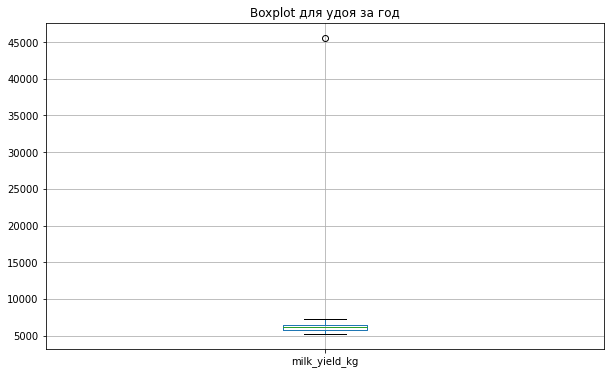

In [23]:
# Создаем график boxplot для столбца 'удой, кг'
plt.figure(figsize=(10, 6))
ferma.boxplot('milk_yield_kg')
plt.title("Boxplot для удоя за год")
plt.show()

In [24]:
# Отфильтруем столбец 'milk_yield_kg' больше или равный 8000
filtered_values = ferma[ferma['milk_yield_kg'] >= 8000]
filtered_values

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio
16,17,более 2 лет,Вис Бик Айдиал,1675,11.5,3.22,Айдиал,холмистое,вкусно,45616,3.076,0.93


In [25]:
# Удалим аномальное значение
ferma = ferma.drop(16)

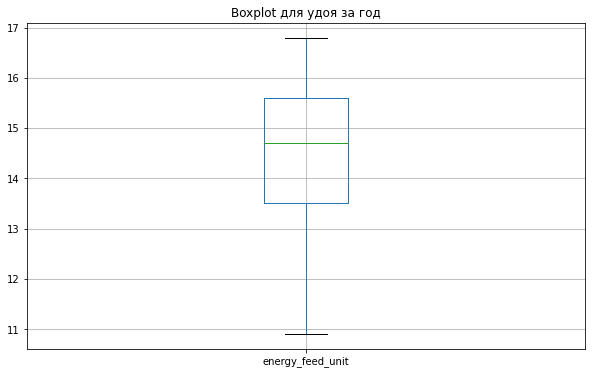

In [26]:
plt.figure(figsize=(10, 6))
ferma.boxplot('energy_feed_unit')
plt.title("Boxplot для удоя за год")
plt.show()

In [27]:
ferma.describe()

,id,crude_protein_g,energy_feed_unit,fat_percentage,milk_yield_kg,protein_percentage,sugar_protein_ratio
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,315.474522,1923.759554,14.548727,3.604268,6125.968153,3.075670,0.913089
std,181.475367,182.832816,1.301777,0.168093,475.857053,0.002551,0.032221
min,1.000000,1660.000000,10.900000,2.990000,5204.000000,3.069000,0.840000
25%,158.750000,1771.750000,13.500000,3.590000,5749.750000,3.074000,0.890000
50%,315.500000,1888.000000,14.700000,3.650000,6132.500000,3.076000,0.930000
75%,472.250000,2062.250000,15.600000,3.720000,6501.000000,3.077000,0.940000
max,629.000000,2349.000000,16.799999,3.750000,7222.000000,3.085000,0.960000


In [28]:
cow_buy.describe()

,fat_percentage,protein_percentage
count,20.000000,20.000000
mean,3.577500,3.069500
std,0.126818,0.010339
min,3.340000,3.046000
25%,3.510000,3.064000
50%,3.590000,3.074000
75%,3.650000,3.076000
max,3.770000,3.081000


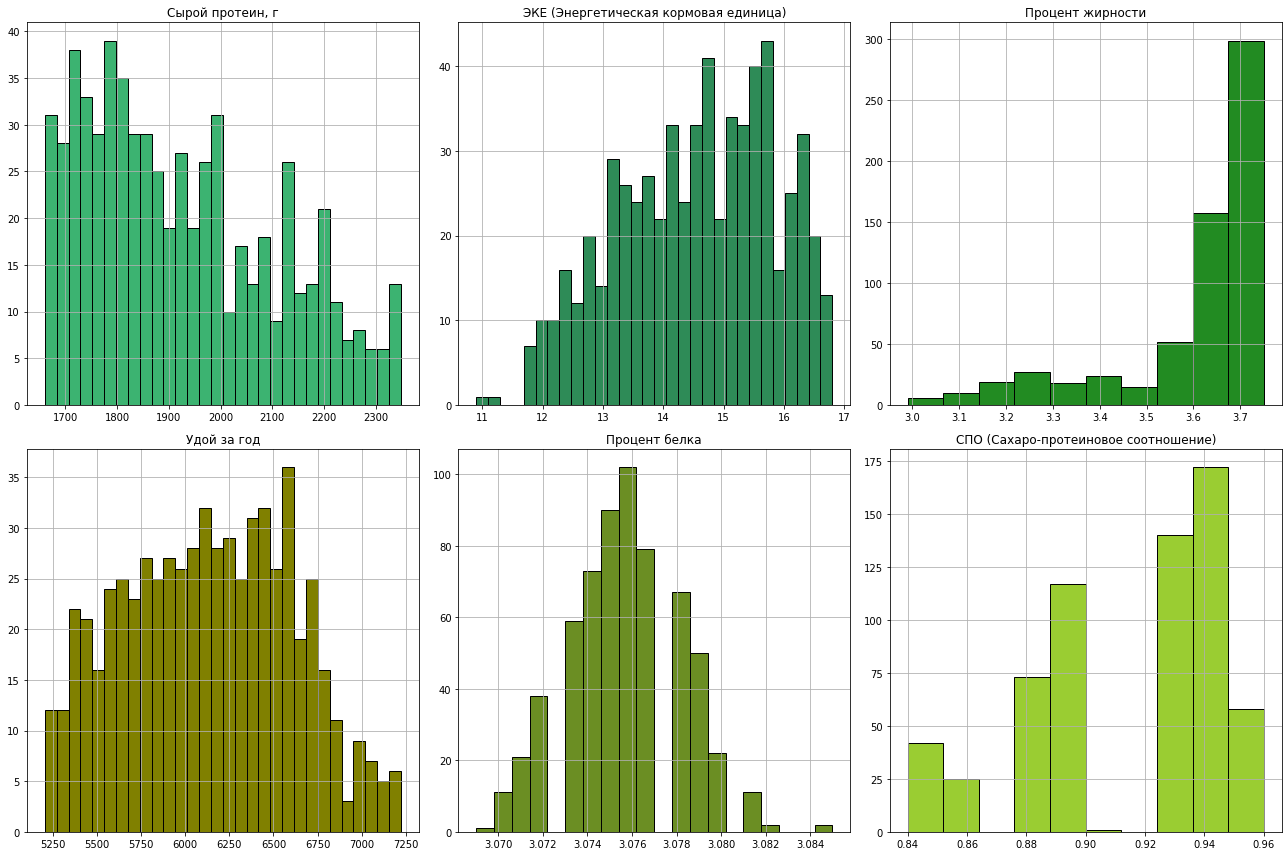

In [29]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

ferma['crude_protein_g'].hist(bins=30, color='MediumSeaGreen', edgecolor='black', ax=axs[0, 0])
axs[0, 0].set_title("Сырой протеин, г")
axs[0, 0].grid(True)

ferma['energy_feed_unit'].hist(bins=30, color='SeaGreen', edgecolor='black', ax=axs[0, 1])
axs[0, 1].set_title("ЭКЕ (Энергетическая кормовая единица)")
axs[0, 1].grid(True)

ferma['fat_percentage'].hist(bins=10, color='ForestGreen', edgecolor='black', ax=axs[0, 2])
axs[0, 2].set_title("Процент жирности")
axs[0, 2].grid(True)

ferma['milk_yield_kg'].hist(bins=30, color='Olive', edgecolor='black', ax=axs[1, 0])
axs[1, 0].set_title("Удой за год")
axs[1, 0].grid(True)

ferma['protein_percentage'].hist(bins=20, color='OliveDrab', edgecolor='black', ax=axs[1, 1])
axs[1, 1].set_title("Процент белка")
axs[1, 1].grid(True)

ferma['sugar_protein_ratio'].hist(bins=10, color='YellowGreen', edgecolor='black', ax=axs[1, 2])
axs[1, 2].set_title("СПО (Сахаро-протеиновое соотношение)")
axs[1, 2].grid(True)

plt.tight_layout()
plt.show()

#### Вывод

Мы проанализировали все данные и обратили внимание на один аномальный показатель удоя коровы — 45 616 литров в год, что кажется невозможным. Поэтому мы исключили это значение.

**1. Сырой протеин, г**

Распределение данных о `crude_protein_g` смещено вправо и близко к биномиальному (умеренно скошенному).

- среднее значение - 1923.75 г
- медианное значение - 1888 г
- минимальное и максимальное значение - 1660 г, 2349 г

**2. ЭКЕ (Энергетическая кормовая единица)**

Данные о `feed_energy_unit` также имеют большой диапазон и увеличиваются.

- среднее значение - 14.54 
- медианное значение - 14.7 
- минимальное и максимальное значение - 10.9, 16.79 

**3. Процент жирности**

Распределение данных о `fat_percentage` имеет длинный хвост слева.

- среднее значение - 3.6 %
- медианное значение - 3.65 %
- минимальное и максимальное значение - 2.99 %, 3.75 %

**4. Удой за год**

Данные о `milk_yield_kg` имеют большой диапазон и увеличиваются до 6600 кг, после чего происходит резкое падение.

- среднее значение - 6125.96 кг
- медианное значение - 6132.5 кг
- минимальное и максимальное значение - 5204 кг, 7222 кг

**5. Процент белка**

Распределение данных о `protein_percentage` имеет форму колокола с небольшим правым хвостом.

- среднее значение - 3.07 %
- медианное значение - 3.07 %
- минимальное и максимальное значение - 3.06 %, 3.08 %

**6. СПО (Сахаро-протеиновое соотношение)**

Распределение данных о `sugar_protein_ratio` имеет два пика.

- среднее значение - 0.91
- медианное значение - 0.93
- минимальное и максимальное значение - 0.84, 0.96

в целом, все в норме

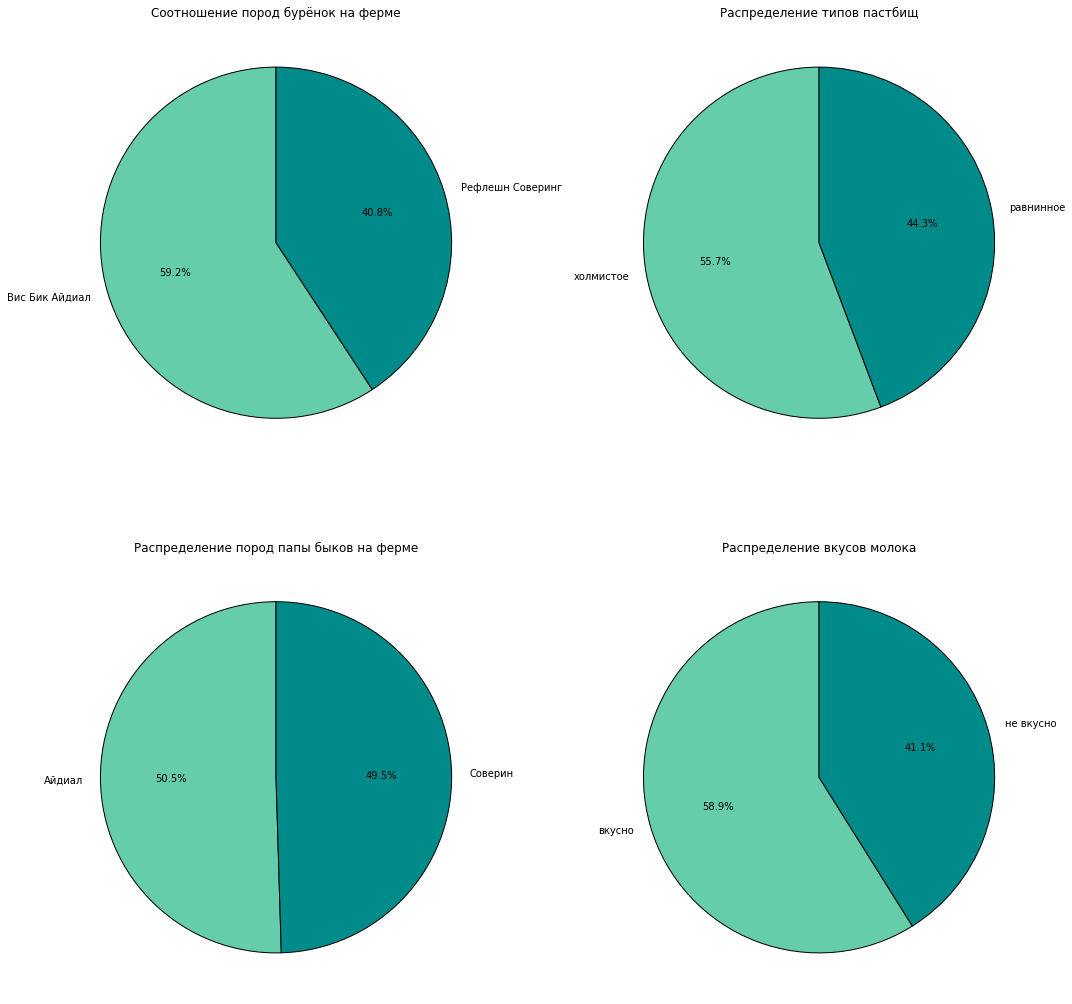

In [30]:
breed_counts = ferma['breed'].value_counts()
grazing_counts = ferma['grazing_type'].value_counts()
father_breed_counts = ferma['father_bull_breed'].value_counts()
flavor_counts = ferma['milk_flavor'].value_counts()

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

wedges, texts, autotexts = axs[0, 0].pie(breed_counts, labels=breed_counts.index, autopct='%1.1f%%', startangle=90, colors=['MediumAquamarine', 'DarkCyan'])
for wedge in wedges:
    wedge.set_edgecolor('black')
axs[0, 0].set_title('Соотношение пород бурёнок на ферме')

wedges, texts, autotexts = axs[0, 1].pie(grazing_counts, labels=grazing_counts.index, autopct='%1.1f%%', startangle=90, colors=['MediumAquamarine', 'DarkCyan'])
for wedge in wedges:
    wedge.set_edgecolor('black')
axs[0, 1].set_title('Распределение типов пастбищ')

wedges, texts, autotexts = axs[1, 0].pie(father_breed_counts, labels=father_breed_counts.index, autopct='%1.1f%%', startangle=90, colors=['MediumAquamarine', 'DarkCyan'])
for wedge in wedges:
    wedge.set_edgecolor('black')
axs[1, 0].set_title('Распределение пород папы быков на ферме')

wedges, texts, autotexts = axs[1, 1].pie(flavor_counts, labels=flavor_counts.index, autopct='%1.1f%%', startangle=90, colors=['MediumAquamarine', 'DarkCyan'])
for wedge in wedges:
    wedge.set_edgecolor('black')
axs[1, 1].set_title('Распределение вкусов молока')

plt.tight_layout()
plt.show()

#### Вывод

1. `Вис Бик Айдиал` превосходит `Рефлешн Соверинг` на 19 %. 
2. `Папы-быки` представлены в породах примерно в равной степени. 
3. 56 % коров пасутся на `холмах`, а 44 % — на `равнинах`. 
4. По оценке фермера, около 41 % всего молока имеет `недостаточное качество вкуса`.

# Корреляционный анализ

### Шаг 4. Проведите корреляционный анализ признаков в датасете ferma_main.csv
1. Изучите взаимосвязь между признаками: рассчитайте коэффициенты корреляции между всеми признаками.

2. Постройте диаграммы рассеяния scatterplot для признака Удой, кг и всех количественных признаков с учётом значения категориальных признаков. Пример: диаграмма рассеяния для Удой, кг и Сырой протеин, г, цвет точек диаграммы отображает признак Порода. Учитывайте, что виды связи в подгруппах могут различаться — например, для разных пород.

3. Сделайте выводы о взаимосвязи признаков.
- Какой тип взаимосвязи между целевым и входными признаками?
- Есть ли нелинейные связи между целевым и входными признаками? Нужно ли вводить в модель дополнительные признаки, чтобы это учесть?
- Наблюдается ли мультиколлинеарность между входными признаками?

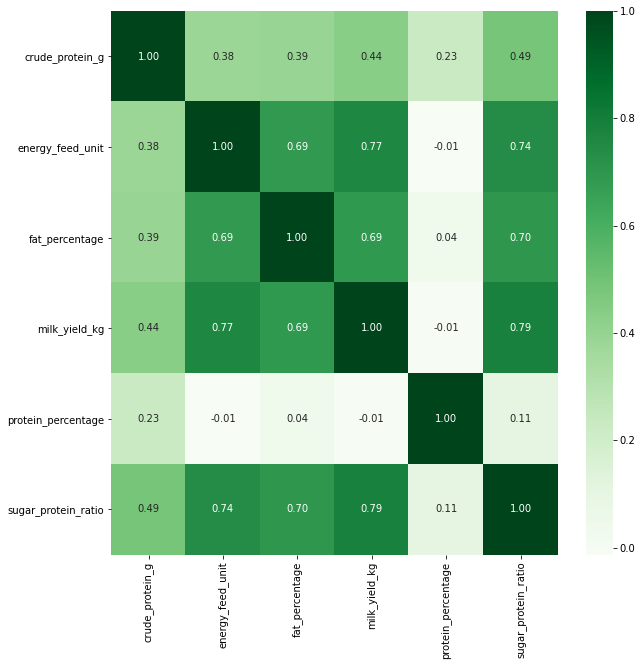

In [31]:
columns_numeric = ['breed', 'crude_protein_g', 'energy_feed_unit', 'fat_percentage', 'milk_yield_kg', 
                   'protein_percentage', 'sugar_protein_ratio']

df_ferma = ferma[columns_numeric]

# Вычислим матрицу корреляции Спирмана
corr_matrix = df_ferma.corr(method='spearman')

# Построим тепловую карту 
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.show()

interval columns not set, guessing: ['crude_protein_g', 'energy_feed_unit', 'fat_percentage', 'milk_yield_kg', 'protein_percentage', 'sugar_protein_ratio']


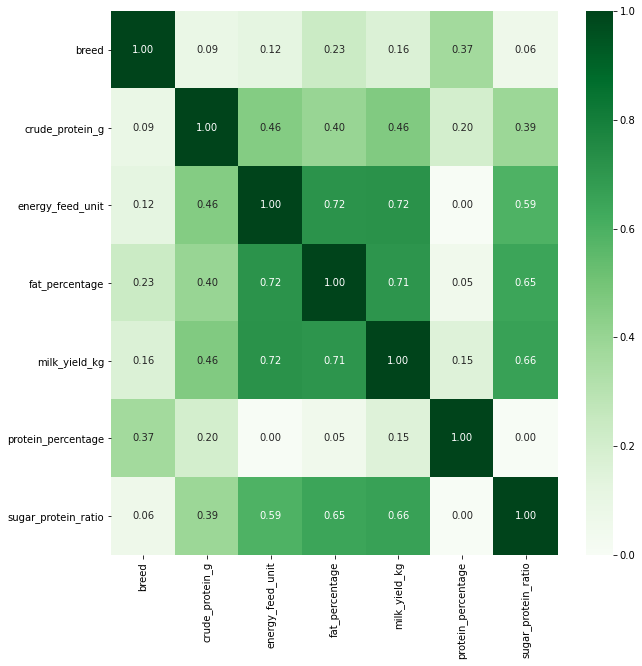

In [32]:
df_phik = df_ferma.phik_matrix()

# Построим тепловую карту 
plt.figure(figsize=(10, 10))
sns.heatmap(df_phik, annot=True, cmap='Greens', fmt=".2f")
plt.show()

In [33]:
df_corr = df_ferma.copy()
df_corr[['milk_yield_kg', 'energy_feed_unit']] = \
df_corr[['milk_yield_kg', 'energy_feed_unit']].apply(lambda x: x ** 2)

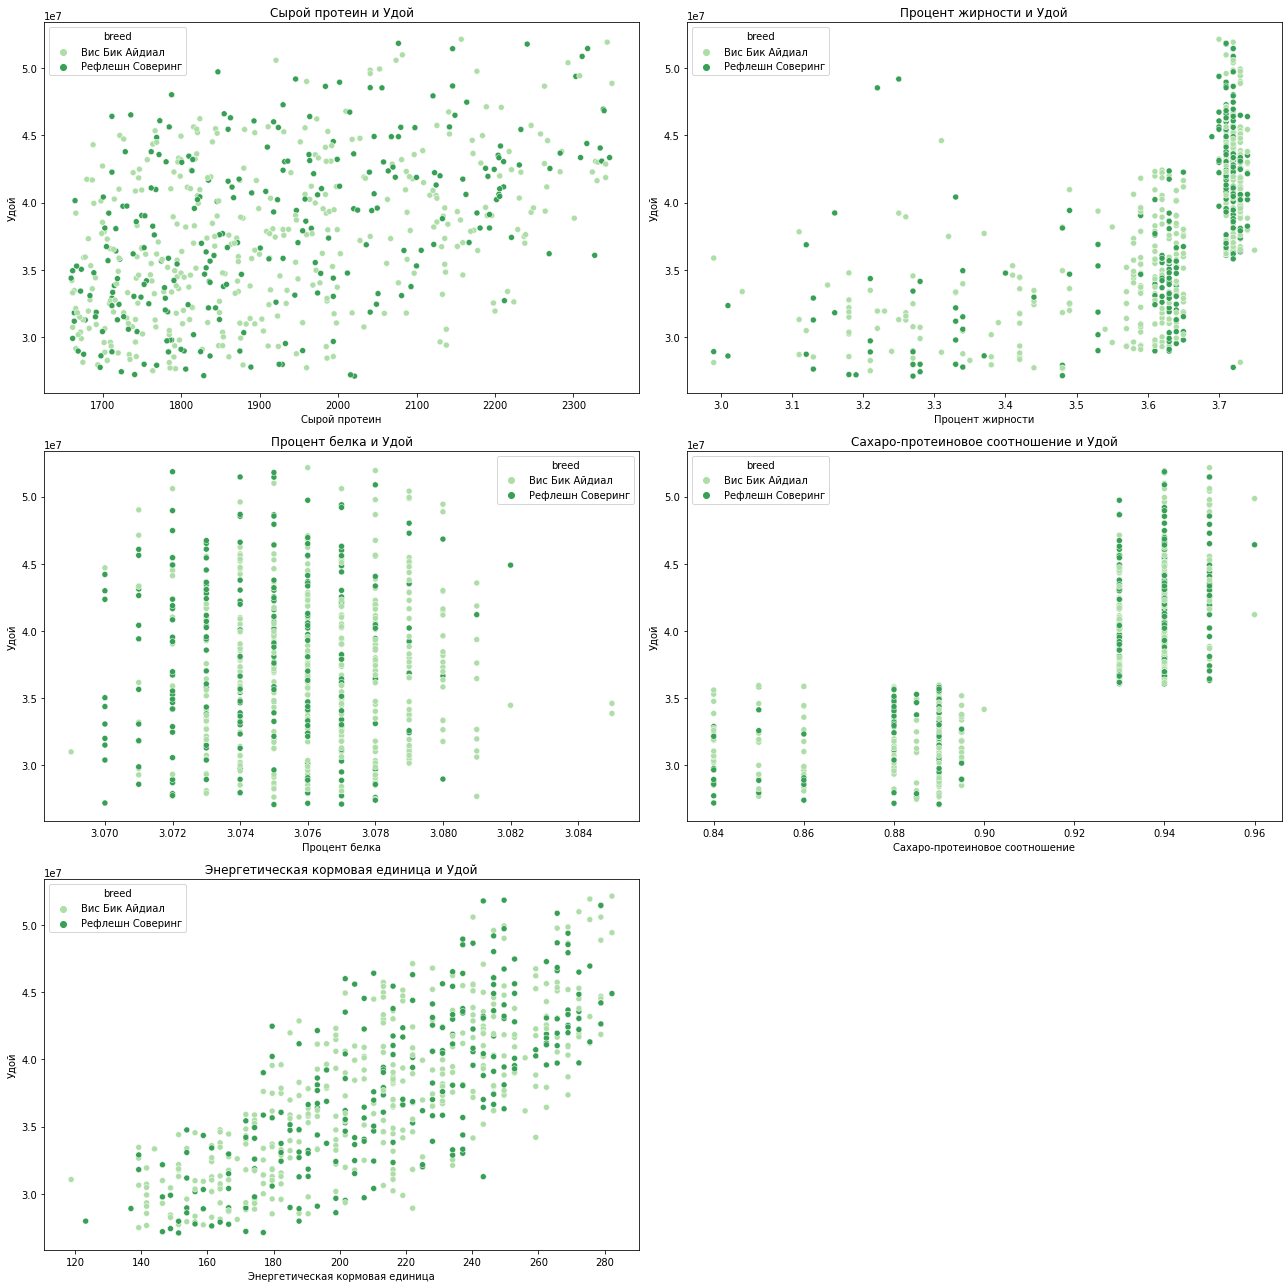

In [34]:
plt.figure(figsize=(18, 18))

# Построение диаграммы рассеяния для 'crude_protein_g'
plt.subplot(3, 2, 1)
sns.scatterplot(x='crude_protein_g', y='milk_yield_kg', hue='breed', data=df_corr, palette='Greens')
plt.title('Сырой протеин и Удой')
plt.xlabel('Сырой протеин')
plt.ylabel('Удой')

# Построение диаграммы рассеяния для 'fat_percentage'
plt.subplot(3, 2, 2)
sns.scatterplot(x='fat_percentage', y='milk_yield_kg', hue='breed', data=df_corr, palette='Greens')
plt.title('Процент жирности и Удой')
plt.xlabel('Процент жирности')
plt.ylabel('Удой')

# Построение диаграммы рассеяния для 'protein_percentage' 
plt.subplot(3, 2, 3)
sns.scatterplot(x='protein_percentage', y='milk_yield_kg', hue='breed', data=df_corr, palette='Greens')
plt.title('Процент белка и Удой')
plt.xlabel('Процент белка')
plt.ylabel('Удой')

# Построение диаграммы рассеяния для 'sugar_protein_ratio' 
plt.subplot(3, 2, 4)
sns.scatterplot(x='sugar_protein_ratio', y='milk_yield_kg', hue='breed', data=df_corr, palette='Greens')
plt.title('Сахаро-протеиновое соотношение и Удой')
plt.xlabel('Сахаро-протеиновое соотношение')
plt.ylabel('Удой')

# Построение диаграммы рассеяния для 'energy_feed_unit' 
plt.subplot(3, 2, 5)
sns.scatterplot(x='energy_feed_unit', y='milk_yield_kg', hue='breed', data=df_corr, palette='Greens')
plt.title('Энергетическая кормовая единица и Удой')
plt.xlabel('Энергетическая кормовая единица')
plt.ylabel('Удой')

plt.tight_layout()
plt.show()

#### Вывод

- **Сырой протеин**: 
положительная линейная зависимость с большим разбросом.
- **Процент жирности**: 
явной линейной зависимости не наблюдается, но при жирности менее 3,5% удой не зависит от жирности. Основные данные распределены вокруг значений 3,6% и 3,7%. Если исключить значения ниже 3,5%, можно заметить некоторую зависимость: чем ближе удой к своему максимуму, тем чаще жирность составляет около 3,7%, и наоборот.
- **Процент белка**: 
зависимости не обнаружено.
- **Сахаро-протеиновое соотношение**:
явной линейной зависимости не наблюдается, однако при удое свыше 6000 значения СПО находятся выше 0,92, что указывает на необходимость перевода в другую категорию с уровнем около 0,92.
- **Энергетическая кормовая единица**: 
положительная нелинейная (квадратичная) зависимость.

# Обучение модели линейной регрессии

### Шаг 5. Задача регрессии
Вам предстоит обучить три модели простой линейной регрессии.
1. Подготовьте данные датасета ferma_main.csv и обучите на них первую модель LinearRegression.
- Используйте в качестве целевого признак Удой, кг.
- Отберите признаки, которые подходят для модели линейной регрессии, аргументируйте выбор. Опирайтесь не только на наличие или отсутствие линейной связи между признаками, но и на причинно-следственные связи между удоем коров и группами признаков из описания датасета.
- Разбейте данные на тренировочную и тестовую выборки.
- Кодируйте категориальные признаки с помощью OneHotEncoder.
- Масштабируйте количественные признаки с помощью StandardScaler.
- Обучите модель линейной регрессии на подготовленных данных.
- Оцените качество модели на тестовой выборке: рассчитайте R², проанализируйте остатки с помощью графиков.
- Оформите выводы, укажите:
    - значение R² модели;
    - какие выводы следуют из анализа остатков;
    - нужны ли дополнительные исследования.
2. Подготовьте данные с учётом связи входных признаков с целевым и обучите на них вторую модель LinearRegression.
- Посмотрите на диаграммы рассеяния: на них можно увидеть, что некоторые входные признаки связаны с целевым нелинейно. Исключите нелинейность, чтобы эти признаки были информативны для линейной регрессии. Вот несколько способов, которыми это можно сделать:
    - Вы обнаружите, что СПО и Удой связаны нелинейно. На их диаграмме рассеяния наблюдения сгруппированы в два кластера, причём есть такое значение СПО, которое можно считать границей между кластерами. Чтобы устранить нелинейность, преобразуйте СПО в категориальный бинарный признак, использовав эту границу.
    - Вы обнаружите, что ЭКЕ и Удой также связаны нелинейно. Нелинейность между ними можно исключить, если ввести новый признак ЭКЕ в квадрате.
- Повторите шаги из пункта 1 и создайте вторую модель: подготовьте данные, обучите модель, оцените её качество и напишите выводы.
3. Добавьте в данные новый признак и обучите на них третью модель LinearRegression.
- Добавьте признак Имя Папы из файла ferma_dad.csv, соединив его с остальными данными ferma_main.csv по ключу.
- Устраните нелинейность между признаками.
- Повторите шаги из пункта 1 и создайте третью модель: подготовьте данные, обучите модель, оцените её качество и напишите выводы.
4. Сравните качество трёх моделей линейной регрессии, сопоставьте их R² и остатки.
5. Оцените качество каждой модели по трём метрикам: MSE, MAE, RMSE. Используйте функции для расчёта метрик.
- Выберите лучшую модель;
- Укажите доверительный интервал прогноза лучшей модели. Для этого рассчитайте квантили ошибки модели на тренировочных данных.
6. С помощью лучшей модели спрогнозируйте удой коров, которых фермер хочет купить. Данные о них находятся в датасете cow_buy.csv.
- Добавьте недостающие признаки ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение): возьмите из датасета ferma_main.csv средние значения каждого из признаков и увеличьте их на 5%.
- Выполните подготовку данных, аналогичную той, которую делали для тренировочной выборки.
- Получите прогноз удоя коров.


## Модель линейной регрессии № 1.

In [35]:
df = ferma.copy()
# Удалим столбцы 'id' и 'milk_flavor'
df = df.drop(['id', 'milk_flavor', 'fat_percentage', 'protein_percentage'], axis=1)
df.head()

,age,breed,crude_protein_g,energy_feed_unit,father_bull_breed,grazing_type,milk_yield_kg,sugar_protein_ratio
0,более 2 лет,Вис Бик Айдиал,1743,14.2,Айдиал,равнинное,5863,0.890
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,Соверин,равнинное,5529,0.890
2,более 2 лет,Рефлешн Соверинг,1854,14.0,Соверин,холмистое,5810,0.885
3,более 2 лет,Рефлешн Соверинг,2012,12.4,Айдиал,холмистое,5895,0.885
4,менее 2 лет,Вис Бик Айдиал,1675,12.8,Соверин,равнинное,5302,0.885


In [36]:
ferma.head(1)

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio
0,1,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,вкусно,5863,3.076,0.89


R2 LinearRegression = 0.78
RSME = 209
MSE = 43887
MAE = 164
Прогнозируемое значение (первая строка) =  6031.538007896169 Реальное значение (первая строка) =  5980


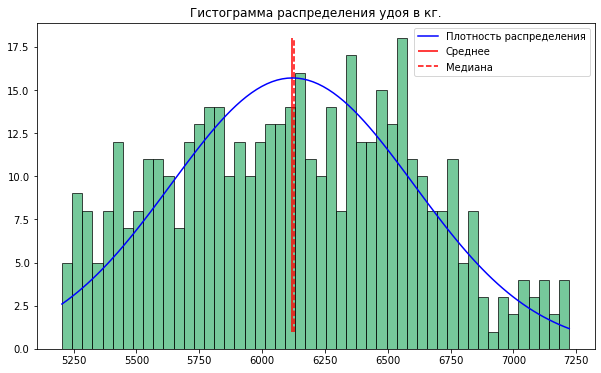

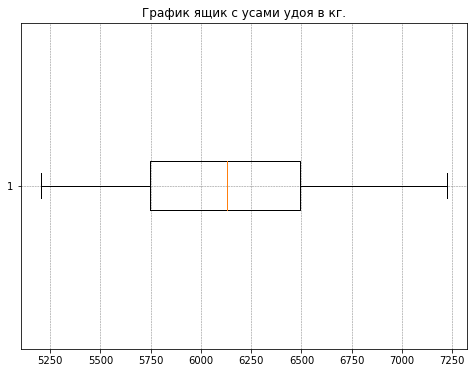

In [37]:
# Создадим модель линейной регрессии 
RANDOM_STATE = 42

X = df.drop(['milk_yield_kg'], axis=1)
y = df['milk_yield_kg']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

cat_col_names = [ 'age', 'breed', 'father_bull_breed', 'grazing_type']
num_col_names = [ 'crude_protein_g', 'energy_feed_unit', 'sugar_protein_ratio']

# Применим OneHotEncoder
encoder_ferma = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder_ferma.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder_ferma.transform(X_test[cat_col_names])

encoder_col_names = encoder_ferma.get_feature_names()

# Применим StandardScaler
scaler_ferma = StandardScaler()
X_train_scaled = scaler_ferma.fit_transform(X_train[num_col_names])
X_test_scaled = scaler_ferma.transform(X_test[num_col_names])
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

# Создадим из них датафрейм
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

# Объединим закодированные и масштабированные признаки
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# Обучим модель линейной регрессии
model_lr1  = LinearRegression()
model_lr1.fit(X_train, y_train)
predictions = model_lr1.predict(X_test)

# Вычислим метрики оценки модели
mae = mean_absolute_error(predictions, y_test)
mse = mean_squared_error(predictions, y_test)
rmse = mean_squared_error(predictions, y_test, squared=False) 
r2 = r2_score(y_test ,predictions)

print(f"R2 LinearRegression = {r2:.2f}")
print(f"RSME = {rmse:.0f}")
print(f'MSE = {mse:.0f}')
print(f'MAE = {mae:.0f}')
print('Прогнозируемое значение (первая строка) = ', predictions[0], 'Реальное значение (первая строка) = ', y_test.reset_index(drop = True)[0])

plt.figure(figsize=(10, 6)) 
bins = plt.hist(y_train, bins=50, color='MediumSeaGreen', edgecolor='black', alpha=0.7) 
plt.vlines(x=y_train.mean(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), label='Среднее')
plt.vlines(x=y_train.median(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), linestyles='--', label='Медиана')
x = np.linspace(min(y_train), max(y_train), 100)
y = 1/(np.sqrt(2*np.pi*np.std(y_train)**2)) * np.exp(-(x-np.mean(y_train))**2/(2*np.std(y_train)**2))
plt.plot(x, y*len(y_train)*np.diff(bins[1])[0], color='blue', label='Плотность распределения')
plt.title('Гистограмма распределения удоя в кг.')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))  
plt.title('График ящик с усами удоя в кг.')
plt.boxplot(y_train, vert=False)
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()

In [38]:
print('95% доверительный интервал =', st.norm.interval(alpha=0.95, loc=np.mean(predictions), scale=st.sem(predictions)))

95% доверительный интервал = (6106.009954727051, 6228.04870362009)


## Модель линейной регрессии № 2.

In [39]:
ferma2 = df.copy()
# Возведем столбец ЭКЕ в квадрат
ferma2['energy_feed_square'] = ferma2['energy_feed_unit'] ** 2
ferma2.head()

,age,breed,crude_protein_g,energy_feed_unit,father_bull_breed,grazing_type,milk_yield_kg,sugar_protein_ratio,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,1743,14.2,Айдиал,равнинное,5863,0.890,201.639999
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,Соверин,равнинное,5529,0.890,163.840012
2,более 2 лет,Рефлешн Соверинг,1854,14.0,Соверин,холмистое,5810,0.885,196.000000
3,более 2 лет,Рефлешн Соверинг,2012,12.4,Айдиал,холмистое,5895,0.885,153.759995
4,менее 2 лет,Вис Бик Айдиал,1675,12.8,Соверин,равнинное,5302,0.885,163.840012


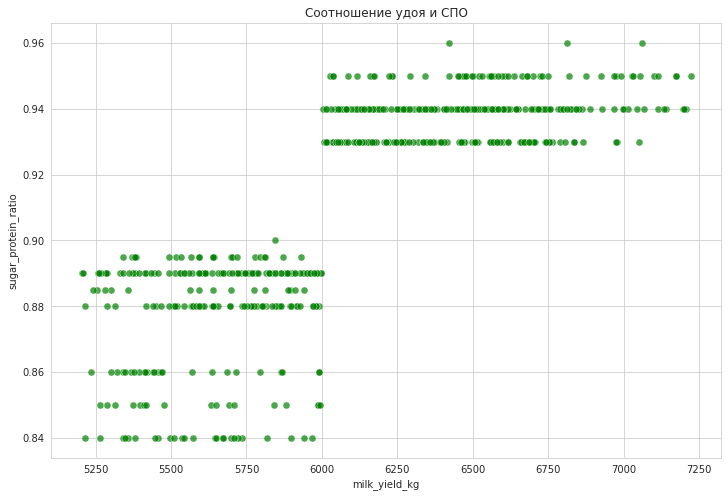

In [40]:
sns.set_style("whitegrid")
sns.scatterplot(x='milk_yield_kg', y='sugar_protein_ratio', data=ferma, s=50, color='green', alpha=0.7)
plt.title("Соотношение удоя и СПО")
plt.gcf().set_size_inches(12, 8)
plt.show()

In [41]:
# Разделим столбец СПО на две группы
ferma2['sugar_protein_ratio'] = ferma2['sugar_protein_ratio'].apply(lambda x: 1 if x >= 0.92 else 0)
ferma2.tail()

,age,breed,crude_protein_g,energy_feed_unit,father_bull_breed,grazing_type,milk_yield_kg,sugar_protein_ratio,energy_feed_square
624,более 2 лет,Рефлешн Соверинг,1964,15.400000,Айдиал,равнинное,6812,1,237.159988
625,менее 2 лет,Рефлешн Соверинг,1700,12.900000,Соверин,равнинное,5513,0,166.409988
626,более 2 лет,Рефлешн Соверинг,1837,14.400000,Соверин,холмистое,5970,0,207.359985
627,более 2 лет,Рефлешн Соверинг,1994,13.800000,Соверин,равнинное,5746,0,190.440002
628,более 2 лет,Вис Бик Айдиал,2283,16.200001,Соверин,холмистое,6503,1,262.440033


R2 LinearRegression = 0.82
RSME = 194
MSE = 37555
MAE = 149
Прогнозируемое значение (первая строка) =  5938.179168699206 Реальное значение (первая строка) =  5980


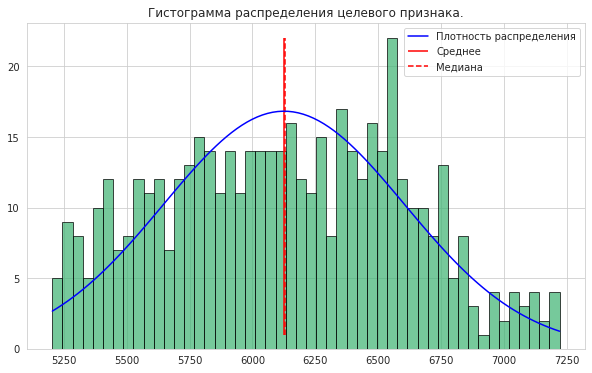

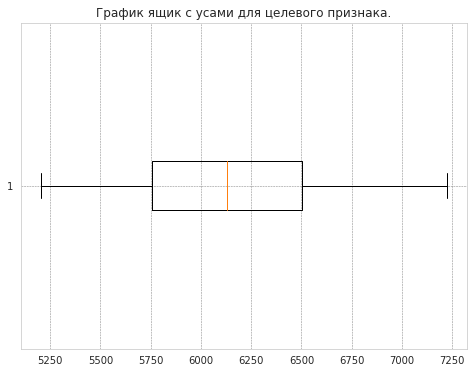

In [42]:
# Создадим модель линейной регрессии 
RANDOM_STATE = 42

X = ferma2.drop('milk_yield_kg', axis=1)
y = ferma2['milk_yield_kg']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

cat_col_names_new = ['age', 'breed', 'father_bull_breed', 'grazing_type', 'sugar_protein_ratio']
num_col_names_new = ['crude_protein_g', 'energy_feed_square']

# Применим OneHotEncoder
encoder_new = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder_new.fit_transform(X_train[cat_col_names_new])
X_test_ohe = encoder_new.transform(X_test[cat_col_names_new])

encoder_col_names_new = encoder_new.get_feature_names()

# Применим StandardScaler
scaler_new = StandardScaler()
X_train_scaled = scaler_new.fit_transform(X_train[num_col_names_new])
X_test_scaled = scaler_new.transform(X_test[num_col_names_new])

# Создадим из них датафрейм
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names_new)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names_new)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_new)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_new)

# Объединим закодированные и масштабированные признаки
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# Обучим модель линейной регрессии
model_lr2  = LinearRegression()
model_lr2.fit(X_train, y_train)
predictions2 = model_lr2.predict(X_test)

# Вычислим метрики оценки модели
mae = mean_absolute_error(predictions2, y_test)
mse = mean_squared_error(predictions2, y_test)
rmse = mean_squared_error(predictions2, y_test, squared=False) 
r2 = r2_score(y_test ,predictions2)

# Выведем метрики оценки модели
print(f"R2 LinearRegression = {r2:.2f}")
print(f"RSME = {rmse:.0f}")
print(f'MSE = {mse:.0f}')
print(f'MAE = {mae:.0f}')
print('Прогнозируемое значение (первая строка) = ', predictions2[0], 'Реальное значение (первая строка) = ', y_test.reset_index(drop = True)[0])

# Построим гистограмму
plt.figure(figsize=(10, 6)) 
bins = plt.hist(y_train, bins=50, color='MediumSeaGreen', edgecolor='black', alpha=0.7)  
plt.vlines(x=y_train.mean(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), label='Среднее')
plt.vlines(x=y_train.median(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), linestyles='--', label='Медиана')
x = np.linspace(min(y_train), max(y_train), 100)
y = 1/(np.sqrt(2*np.pi*np.std(y_train)**2)) * np.exp(-(x-np.mean(y_train))**2/(2*np.std(y_train)**2))
plt.plot(x, y*len(y_train)*np.diff(bins[1])[0], color='blue', label='Плотность распределения')
plt.title('Гистограмма распределения целевого признака.')
plt.legend()
plt.show()

# Построим ящик с усами
plt.figure(figsize=(8, 6))  
plt.title('График ящик с усами для целевого признака.')
plt.boxplot(y_train, vert=False)
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()

In [43]:
print('95% доверительный интервал =', st.norm.interval(alpha=0.95, loc=np.mean(predictions2), scale=st.sem(predictions2)))

95% доверительный интервал = (6084.731427971784, 6224.758924227023)


## Модель линейной регрессии № 3.

In [44]:
# Объединим ferma и dad по столбцу 'id'
merge_df = ferma.merge(dad, on ='id', how='inner')
merge_df.head()

,id,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio,father_name
0,1,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,вкусно,5863,3.076,0.890,Буйный
1,2,менее 2 лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,равнинное,вкусно,5529,3.079,0.890,Соловчик
2,3,более 2 лет,Рефлешн Соверинг,1854,14.0,3.59,Соверин,холмистое,не вкусно,5810,3.074,0.885,Барин
3,4,более 2 лет,Рефлешн Соверинг,2012,12.4,3.40,Айдиал,холмистое,не вкусно,5895,3.075,0.885,Буйный
4,5,менее 2 лет,Вис Бик Айдиал,1675,12.8,3.73,Соверин,равнинное,вкусно,5302,3.073,0.885,Барин


In [45]:
# Теперь удалим столбцы 
merge_df = merge_df.drop(['id', 'fat_percentage', 'milk_flavor', 'protein_percentage'], axis=1)

In [46]:
merge_df=merge_df[['age', 'breed', 'crude_protein_g', 'energy_feed_unit',
       'father_bull_breed', 'grazing_type', 'milk_yield_kg',
       'sugar_protein_ratio', 'father_name']]

In [47]:
# Возведем столбец ЭКЕ в квадрат 
merge_df['energy_feed_square'] = merge_df['energy_feed_unit'] ** 2
merge_df.head(2)

,age,breed,crude_protein_g,energy_feed_unit,father_bull_breed,grazing_type,milk_yield_kg,sugar_protein_ratio,father_name,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,1743,14.2,Айдиал,равнинное,5863,0.89,Буйный,201.639999
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,Соверин,равнинное,5529,0.89,Соловчик,163.840012


In [48]:
# Категоризируем данные
merge_df['sugar_protein_ratio'] = merge_df['sugar_protein_ratio'].apply(lambda x: 1 if x >= 0.92 else 0)

R2 LinearRegression = 0.83
RSME = 187
MSE = 34994
MAE = 145
Прогнозируемое значение (первая строка) =  6007.562216284397 Реальное значение (первая строка) =  5980


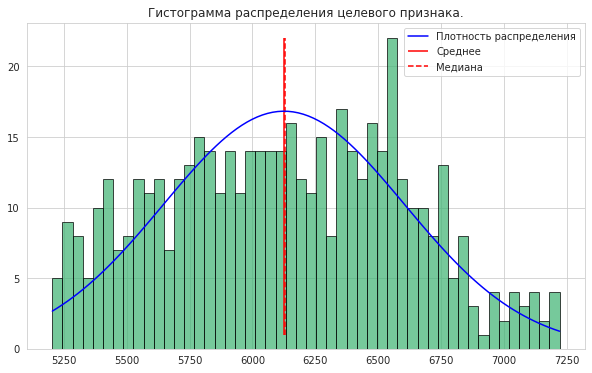

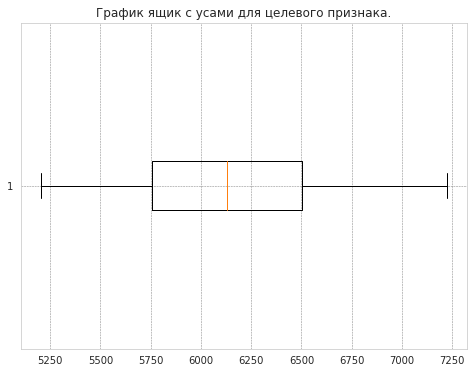

In [49]:
# Создадим модель линейной регрессии 
RANDOM_STATE = 42

X = merge_df.drop('milk_yield_kg', axis=1)
y = merge_df['milk_yield_kg']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

cat_col_names_dad = ['age', 'breed', 'father_bull_breed', 'sugar_protein_ratio', 'grazing_type', 'father_name']
num_col_names_dad = ['crude_protein_g', 'energy_feed_square']

# Применим OneHotEncoder
encoder_dad = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder_dad.fit_transform(X_train[cat_col_names_dad])
X_test_ohe = encoder_dad.transform(X_test[cat_col_names_dad])

encoder_col_names_dad = encoder_dad.get_feature_names()

# Применим StandardScaler
scaler_dad = StandardScaler()
X_train_scaled = scaler_dad.fit_transform(X_train[num_col_names_dad])
X_test_scaled = scaler_dad.transform(X_test[num_col_names_dad])

# Создадим из них датафрейм
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names_dad)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names_dad)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_dad)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_dad)

# Объединим закодированные и масштабированные признаки
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# Обучим модель линейной регрессии
model_lr3  = LinearRegression()
model_lr3.fit(X_train, y_train)
predictions3 = model_lr3.predict(X_test)

# Вычислим метрики оценки модели
mae = mean_absolute_error(predictions3, y_test)
mse = mean_squared_error(predictions3, y_test)
rmse = mean_squared_error(predictions3, y_test, squared=False) 
r2 = r2_score(y_test ,predictions3)

# Выведем метрики оценки модели
print(f"R2 LinearRegression = {r2:.2f}")
print(f"RSME = {rmse:.0f}")
print(f'MSE = {mse:.0f}')
print(f'MAE = {mae:.0f}')
print('Прогнозируемое значение (первая строка) = ', predictions3[0], 'Реальное значение (первая строка) = ', y_test.reset_index(drop = True)[0])

# Построим гистограмму
plt.figure(figsize=(10, 6)) 
bins = plt.hist(y_train, bins=50, color='MediumSeaGreen', edgecolor='black', alpha=0.7) 
plt.vlines(x=y_train.mean(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), label='Среднее')
plt.vlines(x=y_train.median(), colors='red', ymin=bins[0].min(), ymax=bins[0].max(), linestyles='--', label='Медиана')
x = np.linspace(min(y_train), max(y_train), 100)
y = 1/(np.sqrt(2*np.pi*np.std(y_train)**2)) * np.exp(-(x-np.mean(y_train))**2/(2*np.std(y_train)**2))
plt.plot(x, y*len(y_train)*np.diff(bins[1])[0], color='blue', label='Плотность распределения')
plt.title('Гистограмма распределения целевого признака.')
plt.legend()
plt.show()

# Построим ящик с усами
plt.figure(figsize=(8, 6))  
plt.title('График ящик с усами для целевого признака.')
plt.boxplot(y_train, vert=False)
plt.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.show()

In [50]:
print('95% доверительный интервал =', st.norm.interval(alpha=0.95, loc=np.mean(predictions3), scale=st.sem(predictions3)))

95% доверительный интервал = (6078.774026206906, 6222.285417505564)


**Промежуточный вывод**

1. **R²**: Измеряет долю дисперсии зависимой переменной, которая объясняется моделью. Значение **R²** может быть от 0 до 1, где 1 означает идеальное соответствие модели данным, а 0 означает, что модель не объясняет вариацию зависимой переменной лучше, чем простое среднее. Чем ближе значение **R²** к 1, тем лучше модель объясняет данные.

2. **RMSE**: Модель с наименьшим значением **RMSE** считается лучшей. **RMSE** вычисляется как квадратный корень из **MSE**. **RMSE** учитывает как величину ошибки, так и ее направление. Чем меньше значение **RMSE**, тем лучше модель. 

3. **MSE**: Модель с наименьшим значением **MSE** считается лучшей. **MSE** вычисляется как среднее квадратов разностей между предсказанными значениями и истинными значениями. Чем ближе значение **MSE** к нулю, тем лучше модель.

4. **MAE**: Модель с наименьшим значением **MAE** считается лучшей. **MAE** вычисляется как среднее абсолютных разностей между предсказанными значениями и истинными значениями. Чем меньше значение **MAE**, тем лучше модель.

**Вывод модели №1**

- Коэффициент детерминации **(R²)** равен 0,80
- Квадратный корень из суммы квадратов ошибок (**RSME**) равен 206
- Общая сумма квадратов ошибок (**MSE**) равна 42393
- Средняя абсолютная ошибка (**MAE**) равна 161

**Вывод модели №2**

- Коэффициент детерминации **(R²)** равен 0,82
- Квадратный корень из суммы квадратов ошибок (**RSME**) равен 194
- Общая сумма квадратов ошибок (**MSE**) равна 37555
- Средняя абсолютная ошибка (**MAE**) равна 149

**Вывод модели №3**

- Коэффициент детерминации **R²** равен 0,83
- Квадратный корень из суммы квадратов ошибок (**RSME**) равен 187
- Общая сумма квадратов ошибок (**MSE**) равна 34994
- Средняя абсолютная ошибка (**MAE**) равна 145

**Модель №3** превосходит остальные благодаря минимальным ошибкам в прогнозах и высокому коэффициенту детерминации **R²**, что указывает на лучшее объяснение изменчивости целевой переменной с помощью набора предикторов. Общее снижение ошибок от первой до третьей модели свидетельствует о повышении качества моделирования в результате добавления новых переменных и оптимизации структуры модели.

In [51]:
cow_buy2=cow_buy.copy()

In [52]:
cow_buy2[['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']] = \
                ferma[['energy_feed_unit', 'crude_protein_g', 'sugar_protein_ratio']].mean()*1.05
cow_buy2.head()

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage,energy_feed_unit,crude_protein_g,sugar_protein_ratio
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,15.276163,2019.947532,0.958744
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081,15.276163,2019.947532,0.958744
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,15.276163,2019.947532,0.958744
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061,15.276163,2019.947532,0.958744
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074,15.276163,2019.947532,0.958744


In [53]:
cow_buy2=cow_buy2[['age', 'breed', 'fat_percentage', 'protein_percentage', 'father_name',
       'grazing_type', 'energy_feed_unit', 'sugar_protein_ratio',
       'crude_protein_g', 'father_bull_breed']]

In [54]:
# Категоризируем значения
cow_buy2['sugar_protein_ratio'] = cow_buy2['sugar_protein_ratio'].apply(lambda x: 1 if x >= 0.92 else 0)

In [55]:
# Изменим тип данных
cow_buy2['energy_feed_square']=cow_buy2['energy_feed_unit']**2
cow_buy2['crude_protein_g'] = cow_buy2['crude_protein_g'].astype('int64')
cow_buy2.head(2)

,age,breed,fat_percentage,protein_percentage,father_name,grazing_type,energy_feed_unit,sugar_protein_ratio,crude_protein_g,father_bull_breed,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,3.58,3.076,Геркулес,холмистое,15.276163,1,2019,Айдиал,233.361168
1,менее 2 лет,Вис Бик Айдиал,3.54,3.081,Буйный,равнинное,15.276163,1,2019,Соверин,233.361168


In [56]:
merge_df.head()

,age,breed,crude_protein_g,energy_feed_unit,father_bull_breed,grazing_type,milk_yield_kg,sugar_protein_ratio,father_name,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,1743,14.2,Айдиал,равнинное,5863,0,Буйный,201.639999
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,Соверин,равнинное,5529,0,Соловчик,163.840012
2,более 2 лет,Рефлешн Соверинг,1854,14.0,Соверин,холмистое,5810,0,Барин,196.000000
3,более 2 лет,Рефлешн Соверинг,2012,12.4,Айдиал,холмистое,5895,0,Буйный,153.759995
4,менее 2 лет,Вис Бик Айдиал,1675,12.8,Соверин,равнинное,5302,0,Барин,163.840012


In [57]:
# Построим модель прогноза удоя 
df1 = encoder_dad.transform(cow_buy2[cat_col_names_dad]) 
df2 = scaler_dad.transform(cow_buy2[num_col_names_dad])

X_test_ohe = pd.DataFrame(df1, columns=encoder_col_names_dad)

X_test_scaled = pd.DataFrame(df2, columns=num_col_names_dad)

X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
result['milk_yield_kg'] = model_lr3.predict(X_test)

In [58]:
result

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage,milk_yield_kg
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081,6349.233672
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061,6595.462311
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074,6536.853704
5,менее 2 лет,Рефлешн Соверинг,3.63,Соверин,Геркулес,равнинное,3.053,6398.980079
6,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240
7,более 2 лет,Вис Бик Айдиал,3.57,Соверин,Буйный,равнинное,3.079,6546.969770
8,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334
9,менее 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.079,6397.726213


#### Вывод

1. Мы подготовили данные из датасета `ferma_main.csv` и обучили первую модель `LinearRegression`. В качестве целевого использовали признак `Удой, кг`. Затем отобрали подходящие признаки, основываясь на причинно-следственных связях между удоем и входными признаками. После этого разделили данные на обучающую и тестовую выборки. Преобразовали категориальные признаки с помощью `OneHotEncoder` и масштабировали количественные признаки с помощью `StandardScaler`. Обучили модель линейной регрессии на подготовленных данных и оценили её качество с помощью `R²`. Анализ остатков показал, что модель хорошо подходит для данных. 

2. Затем мы подготовили данные с учётом связи входных признаков с целевым и обучили вторую модель `LinearRegression`. Устранили нелинейность между некоторыми входными признаками, преобразовав `СПО` в категориальный бинарный признак и введя новый признак `ЭКЕ` в квадрате. Качество модели улучшилось по сравнению с первой моделью.

3. После этого добавили новый признак `Имя папы` и обучили третью модель `LinearRegression`. Устранили нелинейность между новыми и старыми признаками. Качество модели осталось на высоком уровне.

4. Далее сравнили качество трёх моделей линейной регрессии по R² и остаткам. Все модели показали хорошие результаты.

5. Затем оценили качество каждой модели по трём метрикам: `MSE`, `MAE` и `RMSE`. Лучшая модель показала наименьшие значения ошибок.

6. В конце с помощью лучшей модели спрогнозировали удой коров, которых фермер хочет купить. <u>Отбор прошли 20 бурёнок</u>. В целом распределение по `породе` коров, `породе папы-быков` и `типе пастбища` особо <u>роли не играет</u>.

# Обучение модели логистической регрессии

### Шаг 6. Задача классификации
1. Подготовьте данные датасета ferma_main.csv и обучите на них модель LogisticRegression.
- Используйте в качестве целевого признак Вкус молока.
- При необходимости преобразуйте имеющиеся или добавьте новые признаки.
- Разбейте данные на тренировочную и тестовую выборки.
- Кодируйте категориальные признаки с помощью OneHotEncoder.
- Масштабируйте количественные признаки с помощью StandardScaler.
- Обучите модель логистической регрессии на подготовленных данных.
- Оцените качество модели на тестовой выборке: рассчитайте метрики accuracy, recall, precision.
- Постройте матрицу ошибок.
2. Проанализируйте модель логистической регрессии.
- Объясните, какая ошибка критичнее всего при покупке коров: первого или второго рода. Помните, что главное для заказчика — вкусное молоко. Сформулируйте ответ с учётом метрик recall и precision, выберите более важную из них.
- Сведите критичную ошибку к нулю: для этого измените порог принадлежности к классам. Ещё раз рассчитайте значения метрик recall и precision. Какое значение порога вы выбрали? Как изменились значения метрик?
- Оформите выводы: скажите, что нужно сделать дальше, исходя из анализа модели?
3. С помощью обученной модели спрогнозируйте вкус молока коров, которых фермер хочет купить. Данные о них находятся в датасете cow_buy.csv.
- Выполните подготовку данных, аналогичную той, которую делали для тренировочной выборки.
- Получите прогноз вкуса молока коров.

In [59]:
milk_flavor = ferma.copy()

In [60]:
# Объединим дф
milk_flavor = milk_flavor.merge(dad, on ='id', how='inner')

In [61]:
# Удалим столбец
milk_flavor = milk_flavor.drop(['id'], axis=1)
milk_flavor.head()

,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio,father_name
0,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,вкусно,5863,3.076,0.890,Буйный
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,равнинное,вкусно,5529,3.079,0.890,Соловчик
2,более 2 лет,Рефлешн Соверинг,1854,14.0,3.59,Соверин,холмистое,не вкусно,5810,3.074,0.885,Барин
3,более 2 лет,Рефлешн Соверинг,2012,12.4,3.40,Айдиал,холмистое,не вкусно,5895,3.075,0.885,Буйный
4,менее 2 лет,Вис Бик Айдиал,1675,12.8,3.73,Соверин,равнинное,вкусно,5302,3.073,0.885,Барин


In [62]:
milk_flavor['milk_flavor'] = milk_flavor['milk_flavor'].replace({'вкусно': 1, 'не вкусно': 0})
milk_flavor['sugar_protein_ratio'] = milk_flavor['sugar_protein_ratio'].apply(lambda x: 1 if x >= 0.92 else 0)

milk_flavor.groupby('milk_flavor', as_index=False).agg({'breed': 'count'})\
.rename(columns={'breed': 'count'})\
.replace({'milk_flavor': {0: 'не вкусно', 1: 'вкусно'}})

,milk_flavor,count
0,не вкусно,258
1,вкусно,370


In [63]:
RANDOM_STATE = 42

X = milk_flavor.drop('milk_flavor', axis=1)
y = milk_flavor['milk_flavor']
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25,
    random_state=RANDOM_STATE
)

cat_col_names_ferma = ['age', 'breed', 'sugar_protein_ratio', 'grazing_type', 'father_name']
num_col_names_ferma = ['energy_feed_unit', 'crude_protein_g', 'fat_percentage',  'protein_percentage']

encoder_ferma = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder_ferma.fit_transform(X_train[cat_col_names_ferma])
X_test_ohe = encoder_ferma.transform(X_test[cat_col_names_ferma])

encoder_col_names_ferma = encoder_ferma.get_feature_names()

scaler_ferma = StandardScaler()
X_train_scaled = scaler_ferma.fit_transform(X_train[num_col_names_ferma])
X_test_scaled = scaler_ferma.transform(X_test[num_col_names_ferma])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names_ferma)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names_ferma)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names_ferma)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names_ferma)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

clf = LogisticRegression() 
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)

recall = recall_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
acc = accuracy_score(y_train, y_pred)

print('Recall:', round(recall, 3))
print('Precision:', round(precision, 3))
print('Accuracy:', round(acc, 3))

Recall: 0.816
Precision: 0.663
Accuracy: 0.641


In [64]:
probabilities_one_valid = clf.predict_proba(X_test)[:,1]

for i in np.arange(0.5, 0.9, 0.02).round(2):
    y_pred = probabilities_one_valid > i
    print('порог: ', i, 'precision: ', precision_score(y_test, y_pred))

порог:  0.5 precision:  0.6229508196721312
порог:  0.52 precision:  0.6302521008403361
порог:  0.54 precision:  0.6434782608695652
порог:  0.56 precision:  0.6517857142857143
порог:  0.58 precision:  0.6862745098039216
порог:  0.6 precision:  0.7263157894736842
порог:  0.62 precision:  0.7619047619047619
порог:  0.64 precision:  0.7746478873239436
порог:  0.66 precision:  0.7580645161290323
порог:  0.68 precision:  0.7735849056603774
порог:  0.7 precision:  0.8444444444444444
порог:  0.72 precision:  0.8378378378378378
порог:  0.74 precision:  0.8620689655172413
порог:  0.76 precision:  0.8695652173913043
порог:  0.78 precision:  0.8
порог:  0.8 precision:  1.0
порог:  0.82 precision:  1.0
порог:  0.84 precision:  1.0
порог:  0.86 precision:  0.0
порог:  0.88 precision:  0.0


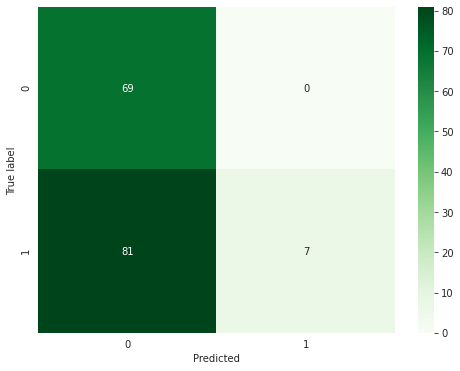

In [65]:

predictions = probabilities_one_valid > 0.8
cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.ylabel('True label')
plt.xlabel('Predicted')
plt.show()

Итого у нас 7 коровподходящих под условия вкусного молока фермера

**Промежуточный вывод**

При прогнозировании вкуса молока у коров мы стремимся снизить количество ошибок, когда модель предсказывает плохой вкус, хотя на самом деле молоко хорошее. Поэтому мы будем работать над повышением полноты (`Recall`), так как это указывает на то, насколько хорошо модель определяет положительные результаты.После определения оптимального порога для классификации, мы выберем порог, который максимизирует метрику `F1-score`, объединяющую точность и полноту модели. Затем используем найденный порог для прогнозирования вкуса молока у коров перед их покупкой.

In [66]:
X_train.head(2)

,x0_менее 2 лет,x1_Рефлешн Соверинг,x2_1,x3_холмистое,x4_Буйный,x4_Геркулес,x4_Соловчик,energy_feed_unit,crude_protein_g,fat_percentage,protein_percentage
0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.502378,1.079523,0.562532,-0.679106
1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,-1.557270,-0.196920,-1.601818,-1.452547


In [67]:
cow_buy2.head(2)

,age,breed,fat_percentage,protein_percentage,father_name,grazing_type,energy_feed_unit,sugar_protein_ratio,crude_protein_g,father_bull_breed,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,3.58,3.076,Геркулес,холмистое,15.276163,1,2019,Айдиал,233.361168
1,менее 2 лет,Вис Бик Айдиал,3.54,3.081,Буйный,равнинное,15.276163,1,2019,Соверин,233.361168


#### Вывод

1. Мы подготовили данные из датасета `ferma_main.csv`: преобразовали категориальные и количественные признаки, разделили данные на тренировочную и тестовую выборки.
2. Категоризовали признаки с использованием `OneHotEncoder`. Масштабировали количественные признаков с применением `StandardScaler`.
3. Обучили модели логистической регрессии на подготовленных данных.
4. Оценили качества модели на тестовой выборке с использованием метрик `accuracy`, `recall`, `precision`.
5. Построили матрицы ошибок и анализ модели логистической регрессии.
6. Определили наиболее важные метрики (`recall` или `precision`) для оценки качества модели.
7. Изменили порог принадлежности к классам для сведения критической ошибки к нулю и повторно рассчитали значений метрик `recall` и `precision`.
8. Спрогнозировали вкуса молока коров из датасета `cow_buy.csv` с использованием обученной модели логистической регрессии.

Таким образом, была успешно выполнена задача по подготовке данных, обучению модели логистической регрессии и прогнозированию вкуса молока коров.

### Шаг 7. 
- Добавьте прогнозы вкуса молока и удоя коров «ЭкоФермы» в датафрейм с коровами, покупку которых рассматривает фермер.
- Отберите коров, для которых спрогнозирован удой более 6000 килограммов в год и вкусное молоко.
- Коротко опишите результаты работы моделей для фермера.
    - Сколько коров он может купить из стада на продажу с минимальным риском для себя? Почему?
    - Какие ещё рекомендации можно ему дать?
- Сделайте выводы о моделях линейной регрессии и логистической регрессии.
    - Какие способы улучшения качества регрессионной модели вы использовали в этой задаче?
    - Возможно ли ещё улучшить результаты регрессионной модели? Если можно, то как? Если нет, то почему?
    - Какие метрики моделей классификации, в том числе логистической регрессии, важны при анализе рисков или экономических расчётов?

In [68]:
cow_buy2['energy_feed_square']=cow_buy2['energy_feed_unit']**2

In [69]:
df3 = encoder_ferma.transform(cow_buy2[cat_col_names_ferma]) 
df4 = scaler_ferma.transform(cow_buy2[num_col_names_ferma])

X_test_ohe_ferma = pd.DataFrame(df3, columns=encoder_col_names_ferma)

X_test_scaled_ferma = pd.DataFrame(df4, columns=num_col_names_ferma)

X_test = pd.concat([X_test_ohe_ferma, X_test_scaled_ferma], axis=1)
result['milk_flavor'] = clf.predict(X_test)


In [70]:
X_test

,x0_менее 2 лет,x1_Рефлешн Соверинг,x2_1,x3_холмистое,x4_Буйный,x4_Геркулес,x4_Соловчик,energy_feed_unit,crude_protein_g,fat_percentage,protein_percentage
0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.566251,0.512215,-0.158919,0.094427
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.566251,0.512215,-0.399402,2.028214
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.566251,0.512215,-0.098798,-0.679106
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.566251,0.512215,-1.241092,-5.706748
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.566251,0.512215,0.201807,-0.679106
5,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.566251,0.512215,0.141687,-8.800788
6,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.566251,0.512215,-0.158919,0.094427
7,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.566251,0.512215,-0.219039,1.254680
8,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.566251,0.512215,-0.098798,-0.679106
9,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.566251,0.512215,-1.241092,1.254680


In [71]:
milk_flavor['energy_feed_square']=milk_flavor['energy_feed_unit']**2
milk_flavor['crude_protein_g'] = milk_flavor['crude_protein_g'].astype('int64')
milk_flavor.head(2)

,age,breed,crude_protein_g,energy_feed_unit,fat_percentage,father_bull_breed,grazing_type,milk_flavor,milk_yield_kg,protein_percentage,sugar_protein_ratio,father_name,energy_feed_square
0,более 2 лет,Вис Бик Айдиал,1743,14.2,3.58,Айдиал,равнинное,1,5863,3.076,0,Буйный,201.639999
1,менее 2 лет,Вис Бик Айдиал,2138,12.8,3.54,Соверин,равнинное,1,5529,3.079,0,Соловчик,163.840012


In [72]:
predicted_probabilities_class = clf.predict_proba(X_test)[:,1] 
result['milk_flavor'] = (predicted_probabilities_class > 0.8).astype(int)
result

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage,milk_yield_kg,milk_flavor
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,0
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081,6349.233672,0
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,0
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061,6595.462311,0
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074,6536.853704,0
5,менее 2 лет,Рефлешн Соверинг,3.63,Соверин,Геркулес,равнинное,3.053,6398.980079,0
6,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,0
7,более 2 лет,Вис Бик Айдиал,3.57,Соверин,Буйный,равнинное,3.079,6546.969770,0
8,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,0
9,менее 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.079,6397.726213,0


In [73]:
result['milk_flavor'] = result['milk_flavor'].apply(lambda x: 'вкусно' if x == 0 else 'не вкусно')

In [74]:
result = result.loc[(result['milk_flavor'] == "вкусно") & (result['milk_yield_kg'] > 6000)]
result

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage,milk_yield_kg,milk_flavor
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,вкусно
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081,6349.233672,вкусно
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,вкусно
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061,6595.462311,вкусно
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074,6536.853704,вкусно
5,менее 2 лет,Рефлешн Соверинг,3.63,Соверин,Геркулес,равнинное,3.053,6398.980079,вкусно
6,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,вкусно
7,более 2 лет,Вис Бик Айдиал,3.57,Соверин,Буйный,равнинное,3.079,6546.969770,вкусно
8,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,вкусно
9,менее 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.079,6397.726213,вкусно


In [75]:
result.describe()

,fat_percentage,protein_percentage,milk_yield_kg
count,20.000000,20.000000,20.000000
mean,3.577500,3.069500,6450.907642
std,0.126818,0.010339,143.644897
min,3.340000,3.046000,6128.706104
25%,3.510000,3.064000,6352.350248
50%,3.590000,3.074000,6467.916892
75%,3.650000,3.076000,6595.462311
max,3.770000,3.081000,6607.431240


In [76]:
result

,age,breed,fat_percentage,father_bull_breed,father_name,grazing_type,protein_percentage,milk_yield_kg,milk_flavor
0,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,вкусно
1,менее 2 лет,Вис Бик Айдиал,3.54,Соверин,Буйный,равнинное,3.081,6349.233672,вкусно
2,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,вкусно
3,более 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.061,6595.462311,вкусно
4,более 2 лет,Рефлешн Соверинг,3.64,Айдиал,Буйный,равнинное,3.074,6536.853704,вкусно
5,менее 2 лет,Рефлешн Соверинг,3.63,Соверин,Геркулес,равнинное,3.053,6398.980079,вкусно
6,более 2 лет,Вис Бик Айдиал,3.58,Айдиал,Геркулес,холмистое,3.076,6607.431240,вкусно
7,более 2 лет,Вис Бик Айдиал,3.57,Соверин,Буйный,равнинное,3.079,6546.969770,вкусно
8,более 2 лет,Рефлешн Соверинг,3.59,Соверин,Барин,равнинное,3.074,6286.722334,вкусно
9,менее 2 лет,Рефлешн Соверинг,3.40,Айдиал,Буйный,холмистое,3.079,6397.726213,вкусно


# Итоговые выводы

#### Вывод

Анализ результатов показал, что из представленного стада фермер может выбрать `20 коров`, которые соответствуют двум важным критериям: годовой удой превышает `6000 кг` и молоко обладает `превосходным вкусом`. Эти коровы считаются наиболее перспективными для покупки, так как они обладают высокой производительностью и качественным продуктом, что делает их приобретение экономически обоснованным с низким уровнем риска. Выбор коров с высокими удоями и приятным вкусом молока повысит рентабельность и удовлетворит потребности покупателей.